# Learning analysis for game length

In [11]:
import os
import chess
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
# Increase font size a bit
plt.rcParams.update({'font.size': 16})

## Function definitions

In [3]:
def get_ordered_unique_values(a):
    x,c = np.unique(a,return_counts=True)
    x = x[np.argsort(c)[::-1]]
    c = np.sort(c)[::-1]
    return x,c

In [4]:
def get_mean_and_sem(x):
    return np.nanmean(x),np.nanstd(x)/np.sqrt(len(x))

## Queen's Gambit

In [5]:
# Load the csv data of QG games (October 2020 - March 2021)
direc = '../../Data/Learning/queens_gambit/'

df = pd.concat([pd.read_csv(direc + 'length_df_{:d}_{:02d}.csv'.format(2020 + j//12,j%12+1),
                            usecols=['white','black','result','fourthmove','game_length'])
                for j in range(9,15)],ignore_index=True)

In [6]:
# Load the pkl data of unique players (March 2020 - September 2020)
players = []
for i in range(3,9):
    with open(direc + 'QG_players_2020_{:02d}.pkl'.format(i),'rb') as f:
        players = pickle.load(f)
s = set(np.array(players).flatten())

# Filter out players who have played the QG in this period
df = df[df['black'].apply(lambda p: not p in s)].reset_index(drop=True)

In [7]:
# Add accept, decline (either the Slav Defense or QG Declined), other to df
df['fourthcode'] = df['fourthmove'].map({'d5c4' : 'A', 'e7e6' : 'D', 'c7c6' : 'D'}).fillna('O')

# Add move index to df
unique_fourthmoves,_ = get_ordered_unique_values(df['fourthmove'].astype(str))
move_to_index = {m:i for i,m in enumerate(unique_fourthmoves)}
df['fourthindex'] = np.array([move_to_index[m] for m in df['fourthmove'].astype(str)])

In [8]:
# View the remaining data
df

,black,white,result,fourthmove,game_length,fourthcode,fourthindex
0,Jimbobnc,Future_Star,1.0,c7c5,87,O,6
1,Hosain_alsaadi,KhaXIIIled_13,0.0,g8f6,23,O,2
2,PekeCatriel,allangargamel,1.0,c7c6,25,D,3
3,victorhugocueto,FlashGilmore,1.0,c7c6,37,D,3
4,hatemylife987987,codnjk,1.0,g8f6,31,O,2
...,...,...,...,...,...,...,...
691232,BySmoot,jruiz10,0.0,d5c4,36,A,0
691233,JDG9234,Sisyfos75,1.0,d5c4,68,A,0
691234,CuzcoMaria17,BlacKing64,1.0,d5c4,81,A,0
691235,florinarnautu,CorporalRivalle,1.0,g8f6,100,O,2


In [9]:
# Create a binary dataframe of just accept/decline
df_binary = df[(df['fourthcode'].isin(['A','D'])) & (~df['result'].isna())].reset_index(drop=True)
names,ind = np.unique(df_binary['black'],return_inverse=True)
name_to_ind = dict(zip(names,ind))

df_binary

,black,white,result,fourthmove,game_length,fourthcode,fourthindex
0,PekeCatriel,allangargamel,1.0,c7c6,25,D,3
1,victorhugocueto,FlashGilmore,1.0,c7c6,37,D,3
2,followill8,HelloTheSecond,1.0,c7c6,35,D,3
3,justben,ozgurwilly,0.0,d5c4,52,A,0
4,followill8,bellatrix111,1.0,c7c6,35,D,3
...,...,...,...,...,...,...,...
480927,sartanc,blindspott,0.0,d5c4,78,A,0
480928,BySmoot,jruiz10,0.0,d5c4,36,A,0
480929,JDG9234,Sisyfos75,1.0,d5c4,68,A,0
480930,CuzcoMaria17,BlacKing64,1.0,d5c4,81,A,0


In [12]:
# Compute the index of the last game as black/white for each QG game
last_game_as_white = [None]*len(df_binary)
last_game_as_black = [None]*len(df_binary)

d_black = defaultdict(lambda: -1)
d_white = defaultdict(lambda: -1)

for i,row in df_binary.iterrows():
    
    last_game_as_white[i] = d_white[row['black']]
    last_game_as_black[i] = d_black[row['black']]
    d_white[row['white']] = i
    d_black[row['black']] = i
    
    if i%100000==0:
        print(i)

0
100000
200000
300000
400000


In [13]:
# Add these to the dataframe
df_binary['last_game_as_white'] = last_game_as_white
df_binary['last_game_as_black'] = last_game_as_black

df_binary

,black,white,result,fourthmove,game_length,fourthcode,fourthindex,last_game_as_white,last_game_as_black
0,PekeCatriel,allangargamel,1.0,c7c6,25,D,3,-1,-1
1,victorhugocueto,FlashGilmore,1.0,c7c6,37,D,3,-1,-1
2,followill8,HelloTheSecond,1.0,c7c6,35,D,3,-1,-1
3,justben,ozgurwilly,0.0,d5c4,52,A,0,-1,-1
4,followill8,bellatrix111,1.0,c7c6,35,D,3,-1,2
...,...,...,...,...,...,...,...,...,...
480927,sartanc,blindspott,0.0,d5c4,78,A,0,-1,480908
480928,BySmoot,jruiz10,0.0,d5c4,36,A,0,-1,-1
480929,JDG9234,Sisyfos75,1.0,d5c4,68,A,0,-1,401683
480930,CuzcoMaria17,BlacKing64,1.0,d5c4,81,A,0,-1,-1


In [14]:
# Compute probability of repetition as a function of game length for the QG
game_length = df_binary['game_length'].values
code = df_binary['fourthcode'].values
length_range = np.arange(0,150,25)

means = [get_mean_and_sem([code[icurr]==code[iprev] for icurr,iprev in enumerate(df_binary['last_game_as_black']) 
                           if iprev>=0 and game_length[iprev]>=length and game_length[iprev]<length+25]) for length in length_range]

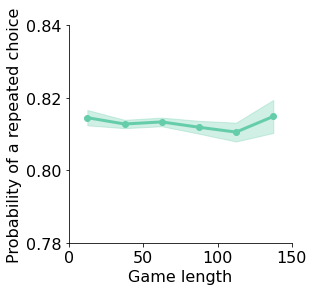

In [16]:
# Plot
fig, ax = plt.subplots(figsize=(4,4))

ax.errorbar(length_range+12.5, [m for m,s in means], marker='o', color='mediumaquamarine', lw=3)
ax.fill_between(length_range+12.5, [m-s for m,s in means], [m+s for m,s in means], color='mediumaquamarine', alpha=0.3)
ax.set_ylabel('Probability of a repeated choice')
ax.set_xlabel('Game length')
ax.set_xlim(0, 150)
ax.set_ylim([0.78,0.84])
ax.set_xticks([0,50,100,150])
ax.set_yticks([0.78,0.8,0.82,0.84])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('RL_length.png', format='png', dpi=1000,bbox_inches = 'tight')

## Sicilian Defense

In [18]:
# Load the csv data of SD games (October 2020 - March 2021)
direc = '../../Data/Learning/sicilian_defense/'

df = pd.concat([pd.read_csv(direc + 'length_df_{:d}_{:02d}.csv'.format(2020 + j//12,j%12+1),
                            usecols=['white','black','result','thirdmove','game_length'])
                for j in range(9,15)],ignore_index=True)

In [19]:
# Load the pkl data of unique players (March 2020 - September 2020)
players = []
for i in range(3,9):
    with open(direc + 'SD_players_2020_{:02d}.pkl'.format(i),'rb') as f:
        players = pickle.load(f)
s = set(np.array(players).flatten())

# Filter out players who have played the SD in this period
df = df[df['white'].apply(lambda p: not p in s)].reset_index(drop=True)

In [20]:
# Add closed, open, or else to df
df['thirdcode'] = df['thirdmove'].map({'b1c3' : 'C', 'g1f3' : 'O'}).fillna('E')

# Add move index to df
unique_thirdmoves,_ = get_ordered_unique_values(df['thirdmove'].astype(str))
move_to_index = {m:i for i,m in enumerate(unique_thirdmoves)}
df['thirdindex'] = np.array([move_to_index[m] for m in df['thirdmove'].astype(str)])

In [21]:
# View the remaining data
df

,black,white,result,thirdmove,game_length,thirdcode,thirdindex
0,Kami_of_Honmaru,wonderingblunder,1.0,b1c3,45,C,3
1,jy3,Scratchman,0.0,g1f3,54,O,0
2,spitecheck,zralybokyma,0.0,f1b5,62,E,12
3,dermaxe,Pandi9595,1.0,b1c3,58,C,3
4,duliomarcio,Raptorax,0.0,g1f3,60,O,0
...,...,...,...,...,...,...,...
1406939,DawsonRicardo,aruniyer88,1.0,g1f3,11,O,0
1406940,Greyuta,Moi555,0.0,a2a3,86,E,15
1406941,Powder36,phildeacon,0.0,d1h5,70,E,4
1406942,Arteaga1811,Kh0nsu,1.0,g1f3,63,O,0


In [22]:
# Create a binary dataframe of just closed/open
df_binary = df[(df['thirdcode'].isin(['C','O'])) & (~df['result'].isna())].reset_index(drop=True)
names,ind = np.unique(df_binary['white'],return_inverse=True)
name_to_ind = dict(zip(names,ind))

df_binary

,black,white,result,thirdmove,game_length,thirdcode,thirdindex
0,Kami_of_Honmaru,wonderingblunder,1.0,b1c3,45,C,3
1,jy3,Scratchman,0.0,g1f3,54,O,0
2,dermaxe,Pandi9595,1.0,b1c3,58,C,3
3,duliomarcio,Raptorax,0.0,g1f3,60,O,0
4,cris15chess2020,AdrianHR2020,1.0,g1f3,49,O,0
...,...,...,...,...,...,...,...
714213,Dancheco,jamin34,1.0,g1f3,57,O,0
714214,Animal-pant,TarumarRiayet,1.0,g1f3,41,O,0
714215,DawsonRicardo,aruniyer88,1.0,g1f3,11,O,0
714216,Arteaga1811,Kh0nsu,1.0,g1f3,63,O,0


In [23]:
# Compute the index of the last game as black/white for each SD game
last_game_as_white = [None]*len(df_binary)
last_game_as_black = [None]*len(df_binary)

d_black = defaultdict(lambda: -1)
d_white = defaultdict(lambda: -1)

for i,row in df_binary.iterrows():
    
    last_game_as_white[i] = d_white[row['white']]
    last_game_as_black[i] = d_black[row['white']]
    d_white[row['white']] = i
    d_black[row['black']] = i
    
    if i%100000==0:
        print(i)

0
100000
200000
300000
400000
500000
600000
700000


In [24]:
# Add these to the dataframe
df_binary['last_game_as_white'] = last_game_as_white
df_binary['last_game_as_black'] = last_game_as_black

df_binary

,black,white,result,thirdmove,game_length,thirdcode,thirdindex,last_game_as_white,last_game_as_black
0,Kami_of_Honmaru,wonderingblunder,1.0,b1c3,45,C,3,-1,-1
1,jy3,Scratchman,0.0,g1f3,54,O,0,-1,-1
2,dermaxe,Pandi9595,1.0,b1c3,58,C,3,-1,-1
3,duliomarcio,Raptorax,0.0,g1f3,60,O,0,-1,-1
4,cris15chess2020,AdrianHR2020,1.0,g1f3,49,O,0,-1,-1
...,...,...,...,...,...,...,...,...,...
714213,Dancheco,jamin34,1.0,g1f3,57,O,0,714199,545842
714214,Animal-pant,TarumarRiayet,1.0,g1f3,41,O,0,713090,713137
714215,DawsonRicardo,aruniyer88,1.0,g1f3,11,O,0,689858,-1
714216,Arteaga1811,Kh0nsu,1.0,g1f3,63,O,0,698226,-1


In [29]:
# Compute probability of repetition as a function of game length for the SD
game_length = df_binary['game_length'].values
code = df_binary['thirdcode'].values
length_range = np.arange(0,150,25)

means = [get_mean_and_sem([code[icurr]==code[iprev] for icurr,iprev in enumerate(df_binary['last_game_as_white']) 
                           if iprev>=0 and game_length[iprev]>=length and game_length[iprev]<length+25]) for length in length_range]

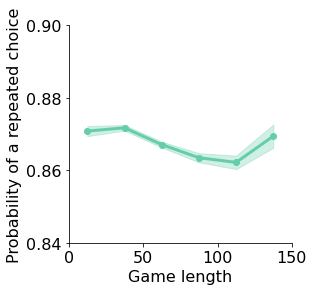

In [32]:
# Plot
fig, ax = plt.subplots(figsize=(4,4))

ax.errorbar(length_range+12.5, [m for m,s in means], marker='o', color='mediumaquamarine', lw=3)
ax.fill_between(length_range+12.5, [m-s for m,s in means], [m+s for m,s in means], color='mediumaquamarine', alpha=0.3)
ax.set_ylabel('Probability of a repeated choice')
ax.set_xlabel('Game length')
ax.set_xlim(0, 150)
ax.set_ylim([0.84,0.90])
ax.set_xticks([0,50,100,150])
ax.set_yticks([0.84,0.86,0.88,0.90])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('RL_length.png', format='png', dpi=1000,bbox_inches = 'tight')

## King's Knight

In [33]:
# Load the csv data of KK games (October 2020 - March 2021)
direc = '../../Data/Learning/kings_knight/'

df = pd.concat([pd.read_csv(direc + 'length_df_{:d}_{:02d}.csv'.format(2020 + j//12,j%12+1),
                            usecols=['white','black','result','fifthmove','game_length'])
                for j in range(9,15)],ignore_index=True)

In [34]:
# Load the pkl data of unique players (March 2020 - September 2020)
players = []
for i in range(3,9):
    with open(direc + 'KK_players_2020_{:02d}.pkl'.format(i),'rb') as f:
        players = pickle.load(f)
s = set(np.array(players).flatten())

# Filter out players who have played the KK in this period
df = df[df['white'].apply(lambda p: not p in s)].reset_index(drop=True)

In [35]:
# Add italian, ruy lopez, or other to df
df['fifthcode'] = df['fifthmove'].map({'f1c4' : 'I', 'f1b5' : 'R'}).fillna('O')

# Add move index to df
unique_fifthmoves,_ = get_ordered_unique_values(df['fifthmove'].astype(str))
move_to_index = {m:i for i,m in enumerate(unique_fifthmoves)}
df['fifthindex'] = np.array([move_to_index[m] for m in df['fifthmove'].astype(str)])

In [36]:
# View the remaining data
df

,black,white,result,fifthmove,game_length,fifthcode,fifthindex
0,RIFQIPEBRIAN123,Daniel_Kundera,0.0,f1c4,34,I,0
1,Vikingo2001,oldmangrayshirt,1.0,f1c4,25,I,0
2,Admin_Noob,apriori96,1.0,b1c3,53,O,1
3,DobbsNZ,gantulg,1.0,f1b5,47,R,2
4,juanibm,KryptideBTW,1.0,d2d4,47,O,3
...,...,...,...,...,...,...,...
2213603,Senku_virtuose,Me4kata,1.0,f1c4,15,I,0
2213604,M2nero,deviengeorge,0.0,f1b5,40,R,2
2213605,TheGeneralZod,xuny,1.0,b1c3,12,O,1
2213606,waggledook,PLVST_Music,1.0,c2c3,117,O,4


In [37]:
# Create a binary dataframe of just italian/ruy lopez
df_binary = df[(df['fifthcode'].isin(['I','R'])) & (~df['result'].isna())].reset_index(drop=True)
names,ind = np.unique(df_binary['white'],return_inverse=True)
name_to_ind = dict(zip(names,ind))

df_binary

,black,white,result,fifthmove,game_length,fifthcode,fifthindex
0,RIFQIPEBRIAN123,Daniel_Kundera,0.0,f1c4,34,I,0
1,Vikingo2001,oldmangrayshirt,1.0,f1c4,25,I,0
2,DobbsNZ,gantulg,1.0,f1b5,47,R,2
3,f1gn2r,AhmedEinstein,0.0,f1c4,66,I,0
4,KnowUrSelf,RSTD2006,1.0,f1c4,75,I,0
...,...,...,...,...,...,...,...
1225905,saani3620,DrewReallyDo,1.0,f1c4,29,I,0
1225906,Panfi,rsastre,0.0,f1b5,70,R,2
1225907,Senku_virtuose,Me4kata,1.0,f1c4,15,I,0
1225908,M2nero,deviengeorge,0.0,f1b5,40,R,2


In [38]:
# Compute the index of the last game as black/white for each KK game
last_game_as_white = [None]*len(df_binary)
last_game_as_black = [None]*len(df_binary)

d_black = defaultdict(lambda: -1)
d_white = defaultdict(lambda: -1)

for i,row in df_binary.iterrows():
    
    last_game_as_white[i] = d_white[row['white']]
    last_game_as_black[i] = d_black[row['white']]
    d_white[row['white']] = i
    d_black[row['black']] = i
    
    if i%100000==0:
        print(i)

0
100000
200000
300000
400000
500000
600000
700000
800000
900000
1000000
1100000
1200000


In [39]:
# Add these to the dataframe
df_binary['last_game_as_white'] = last_game_as_white
df_binary['last_game_as_black'] = last_game_as_black

df_binary

,black,white,result,fifthmove,game_length,fifthcode,fifthindex,last_game_as_white,last_game_as_black
0,RIFQIPEBRIAN123,Daniel_Kundera,0.0,f1c4,34,I,0,-1,-1
1,Vikingo2001,oldmangrayshirt,1.0,f1c4,25,I,0,-1,-1
2,DobbsNZ,gantulg,1.0,f1b5,47,R,2,-1,-1
3,f1gn2r,AhmedEinstein,0.0,f1c4,66,I,0,-1,-1
4,KnowUrSelf,RSTD2006,1.0,f1c4,75,I,0,-1,-1
...,...,...,...,...,...,...,...,...,...
1225905,saani3620,DrewReallyDo,1.0,f1c4,29,I,0,1225340,1185551
1225906,Panfi,rsastre,0.0,f1b5,70,R,2,1225187,-1
1225907,Senku_virtuose,Me4kata,1.0,f1c4,15,I,0,1225807,1225571
1225908,M2nero,deviengeorge,0.0,f1b5,40,R,2,-1,-1


In [40]:
# Compute probability of repetition as a function of game length for the KK
game_length = df_binary['game_length'].values
code = df_binary['fifthcode'].values
length_range = np.arange(0,150,25)

means = [get_mean_and_sem([code[icurr]==code[iprev] for icurr,iprev in enumerate(df_binary['last_game_as_white']) 
                           if iprev>=0 and game_length[iprev]>=length and game_length[iprev]<length+25]) for length in length_range]

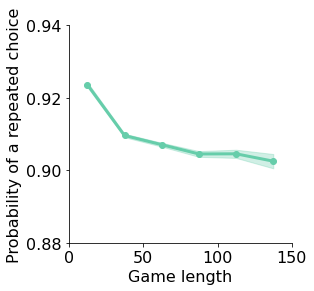

In [42]:
# Plot
fig, ax = plt.subplots(figsize=(4,4))

ax.errorbar(length_range+12.5, [m for m,s in means], marker='o', color='mediumaquamarine', lw=3)
ax.fill_between(length_range+12.5, [m-s for m,s in means], [m+s for m,s in means], color='mediumaquamarine', alpha=0.3)
ax.set_ylabel('Probability of a repeated choice')
ax.set_xlabel('Game length')
ax.set_xlim(0, 150)
ax.set_ylim([0.88,0.94])
ax.set_xticks([0,50,100,150])
ax.set_yticks([0.88,0.90,0.92,0.94])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('RL_length.png', format='png', dpi=1000,bbox_inches = 'tight')

## Caro-Kann Defense

In [43]:
# Load the csv data of CK games (October 2020 - March 2021)
direc = '../../Data/Learning/caro_kann/'

df = pd.concat([pd.read_csv(direc + 'length_df_{:d}_{:02d}.csv'.format(2020 + j//12,j%12+1),
                            usecols=['white','black','result','fifthmove','game_length'])
                for j in range(9,15)],ignore_index=True)

In [44]:
# Load the pkl data of unique players (March 2020 - September 2020)
players = []
for i in range(3,9):
    with open(direc + 'CK_players_2020_{:02d}.pkl'.format(i),'rb') as f:
        players = pickle.load(f)
s = set(np.array(players).flatten())

# Filter out players who have played the KK in this period
df = df[df['white'].apply(lambda p: not p in s)].reset_index(drop=True)

In [45]:
# Add advance, exchange, or other to df
df['fifthcode'] = df['fifthmove'].map({'e4e5' : 'A', 'e4d5' : 'E'}).fillna('O')

# Add move index to df
unique_fifthmoves,_ = get_ordered_unique_values(df['fifthmove'].astype(str))
move_to_index = {m:i for i,m in enumerate(unique_fifthmoves)}
df['fifthindex'] = np.array([move_to_index[m] for m in df['fifthmove'].astype(str)])

In [46]:
# View the remaining data
df

,black,white,result,fifthmove,game_length,fifthcode,fifthindex
0,xhessfolife,math_floor,0.0,e4e5,60,A,0
1,SrGordito,ridwani,1.0,b1c3,39,O,2
2,simplex2185,Eweheg,0.0,e4d5,48,E,1
3,wilsonericn,apriori96,1.0,e4e5,59,A,0
4,prowessjen,gop2cob,1.0,e4d5,85,E,1
...,...,...,...,...,...,...,...
117420,SrPinguin,tobezors,0.0,b1c3,58,O,2
117421,EvDawg74,Arkadaslarimiz,0.0,e4e5,52,A,0
117422,ojor_the_ancient,ThomasRiordan,0.0,e4d5,28,E,1
117423,javlaF,orthojb,0.0,e4e5,48,A,0


In [47]:
# Create a binary dataframe of just advance/exchange
df_binary = df[(df['fifthcode'].isin(['A','E'])) & (~df['result'].isna())].reset_index(drop=True)
names,ind = np.unique(df_binary['white'],return_inverse=True)
name_to_ind = dict(zip(names,ind))

df_binary

,black,white,result,fifthmove,game_length,fifthcode,fifthindex
0,xhessfolife,math_floor,0.0,e4e5,60,A,0
1,simplex2185,Eweheg,0.0,e4d5,48,E,1
2,wilsonericn,apriori96,1.0,e4e5,59,A,0
3,prowessjen,gop2cob,1.0,e4d5,85,E,1
4,RErwin,MoinZenMeister,0.0,e4d5,114,E,1
...,...,...,...,...,...,...,...
78718,EvDawg74,Katers100,0.0,e4d5,34,E,1
78719,EvDawg74,Arkadaslarimiz,0.0,e4e5,52,A,0
78720,ojor_the_ancient,ThomasRiordan,0.0,e4d5,28,E,1
78721,javlaF,orthojb,0.0,e4e5,48,A,0


In [48]:
# Compute the index of the last game as black/white for each CK game
last_game_as_white = [None]*len(df_binary)
last_game_as_black = [None]*len(df_binary)

d_black = defaultdict(lambda: -1)
d_white = defaultdict(lambda: -1)

for i,row in df_binary.iterrows():
    
    last_game_as_white[i] = d_white[row['white']]
    last_game_as_black[i] = d_black[row['white']]
    d_white[row['white']] = i
    d_black[row['black']] = i
    
    if i%100000==0:
        print(i)

0


In [49]:
# Add these to the dataframe
df_binary['last_game_as_white'] = last_game_as_white
df_binary['last_game_as_black'] = last_game_as_black

df_binary

,black,white,result,fifthmove,game_length,fifthcode,fifthindex,last_game_as_white,last_game_as_black
0,xhessfolife,math_floor,0.0,e4e5,60,A,0,-1,-1
1,simplex2185,Eweheg,0.0,e4d5,48,E,1,-1,-1
2,wilsonericn,apriori96,1.0,e4e5,59,A,0,-1,-1
3,prowessjen,gop2cob,1.0,e4d5,85,E,1,-1,-1
4,RErwin,MoinZenMeister,0.0,e4d5,114,E,1,-1,-1
...,...,...,...,...,...,...,...,...,...
78718,EvDawg74,Katers100,0.0,e4d5,34,E,1,73592,-1
78719,EvDawg74,Arkadaslarimiz,0.0,e4e5,52,A,0,-1,-1
78720,ojor_the_ancient,ThomasRiordan,0.0,e4d5,28,E,1,69007,-1
78721,javlaF,orthojb,0.0,e4e5,48,A,0,76586,-1


In [50]:
# Compute probability of repetition as a function of game length for the KK
game_length = df_binary['game_length'].values
code = df_binary['fifthcode'].values
length_range = np.arange(0,150,25)

means = [get_mean_and_sem([code[icurr]==code[iprev] for icurr,iprev in enumerate(df_binary['last_game_as_white']) 
                           if iprev>=0 and game_length[iprev]>=length and game_length[iprev]<length+25]) for length in length_range]

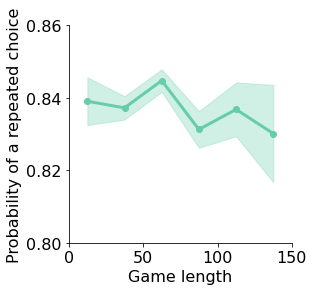

In [54]:
# Plot
fig, ax = plt.subplots(figsize=(4,4))

ax.errorbar(length_range+12.5, [m for m,s in means], marker='o', color='mediumaquamarine', lw=3)
ax.fill_between(length_range+12.5, [m-s for m,s in means], [m+s for m,s in means], color='mediumaquamarine', alpha=0.3)
ax.set_ylabel('Probability of a repeated choice')
ax.set_xlabel('Game length')
ax.set_xlim(0, 150)
ax.set_ylim([0.80,0.86])
ax.set_xticks([0,50,100,150])
ax.set_yticks([0.80,0.82,0.84,0.86])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('RL_length.png', format='png', dpi=1000,bbox_inches = 'tight')